# WMDP Benchmark Baseline Analysis

Verifies blog claims B1-B5 about baseline (no inception attack) refusal rates and inception uplift.

**Claims:**
- **B1**: 90.6-96.9% refusal at baseline (excluding OpenThinker)
- **B2**: Inception uplift +77 to +93 pp; mean +88.1 pp
- **B3**: Think vs instruct not significant at baseline (p=0.416)
- **B4**: Chem slightly higher compliance than bio at baseline
- **B5**: OpenThinker3-7B outlier at 97.5% compliance

## 1. Setup

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

ROOT = Path('/home/md2292/inception-eval')
BENCH_ROOT = ROOT / 'evaluation/eval_deepseek_judge/benchmark'
M5_ROOT = ROOT / 'evaluation/eval_deepseek_judge/max_iterations_5'
CUMULATIVE = BENCH_ROOT / 'cumulative/benchmark_danger_scores.pickle'

OPENTHINKER = 'OpenThinker3-7B'

## 2. Load baseline & M5 per-model dataframes

In [2]:
def load_variant(root: Path) -> dict:
    """Load all {variant}/{model}/{model}_safety_judge.pickle into a dict keyed by (variant, model)."""
    out = {}
    for variant in ['think', 'instruct']:
        vdir = root / variant
        if not vdir.exists():
            continue
        for mdir in sorted(vdir.iterdir()):
            if not mdir.is_dir():
                continue
            pkl = mdir / f'{mdir.name}_safety_judge.pickle'
            if pkl.exists():
                out[(variant, mdir.name)] = pd.read_pickle(pkl)
    return out

baseline = load_variant(BENCH_ROOT)
m5 = load_variant(M5_ROOT)
print(f'Baseline models: {len(baseline)} | M5 models: {len(m5)}')
for k in baseline: print(' baseline', k, baseline[k].shape)
for k in m5: print(' m5      ', k, m5[k].shape)

Baseline models: 13 | M5 models: 10
 baseline ('think', 'DeepSeek-R1-0528') (800, 34)
 baseline ('think', 'DeepSeek-V3.2') (800, 34)
 baseline ('think', 'GLM-4.6') (800, 34)
 baseline ('think', 'GPT-OSS-120B') (800, 34)
 baseline ('think', 'Kimi-K2-Thinking') (800, 34)
 baseline ('think', 'OpenThinker3-7B') (800, 34)
 baseline ('think', 'Qwen3-235B-A22B-Thinking-2507') (800, 34)
 baseline ('think', 'Qwen3-Next-80B-A3B-Thinking') (800, 34)
 baseline ('instruct', 'DeepSeek-V3.2') (800, 34)
 baseline ('instruct', 'GLM-4.6') (800, 34)
 baseline ('instruct', 'Kimi-K2-Instruct-0905') (800, 34)
 baseline ('instruct', 'Qwen3-235B-A22B-Instruct-2507') (800, 34)
 baseline ('instruct', 'Qwen3-Next-80B-A3B-Instruct') (800, 34)
 m5       ('think', 'DeepSeek-R1-0528') (800, 41)
 m5       ('think', 'DeepSeek-V3.2') (800, 41)
 m5       ('think', 'GLM-4.6') (800, 41)
 m5       ('think', 'GPT-OSS-120B') (800, 41)
 m5       ('think', 'Qwen3-235B-A22B-Thinking-2507') (800, 41)
 m5       ('instruct', 'Deep

## 3. Per-model baseline compliance

In [3]:
def compliance_pct(df: pd.DataFrame) -> float:
    return 100.0 * df['complied'].astype(bool).mean()

rows = []
for (variant, model), df in baseline.items():
    rows.append({
        'variant': variant,
        'model': model,
        'compliance_pct': compliance_pct(df),
        'n': len(df),
    })
baseline_df = pd.DataFrame(rows).sort_values('compliance_pct', ascending=False).reset_index(drop=True)
baseline_df['refusal_pct'] = 100.0 - baseline_df['compliance_pct']
print(baseline_df.to_string(index=False))

 variant                         model  compliance_pct   n  refusal_pct
   think               OpenThinker3-7B          97.500 800        2.500
instruct         Kimi-K2-Instruct-0905           9.375 800       90.625
instruct                 DeepSeek-V3.2           8.125 800       91.875
   think                       GLM-4.6           8.000 800       92.000
   think              DeepSeek-R1-0528           7.750 800       92.250
   think              Kimi-K2-Thinking           7.750 800       92.250
   think Qwen3-235B-A22B-Thinking-2507           7.500 800       92.500
instruct Qwen3-235B-A22B-Instruct-2507           6.875 800       93.125
instruct   Qwen3-Next-80B-A3B-Instruct           6.625 800       93.375
instruct                       GLM-4.6           6.500 800       93.500
   think                  GPT-OSS-120B           3.500 800       96.500
   think                 DeepSeek-V3.2           3.375 800       96.625
   think   Qwen3-Next-80B-A3B-Thinking           3.125 800      

In [4]:
# Refusal range excluding OpenThinker outlier
no_outlier = baseline_df[baseline_df['model'] != OPENTHINKER]
ref_min, ref_max = no_outlier['refusal_pct'].min(), no_outlier['refusal_pct'].max()
mean_compl = baseline_df['compliance_pct'].mean()
mean_compl_no = no_outlier['compliance_pct'].mean()
print(f'Refusal range (excl. OpenThinker): {ref_min:.1f}% - {ref_max:.1f}%')
print(f'Mean baseline compliance (all):           {mean_compl:.2f}%')
print(f'Mean baseline compliance (excl. outlier): {mean_compl_no:.2f}%')
print(f'OpenThinker3-7B compliance: {baseline_df.loc[baseline_df.model==OPENTHINKER, "compliance_pct"].values}')

Refusal range (excl. OpenThinker): 90.6% - 96.9%
Mean baseline compliance (all):           13.54%
Mean baseline compliance (excl. outlier): 6.54%
OpenThinker3-7B compliance: [97.5]


## 4. Figure 1 - Baseline compliance by model (sorted)

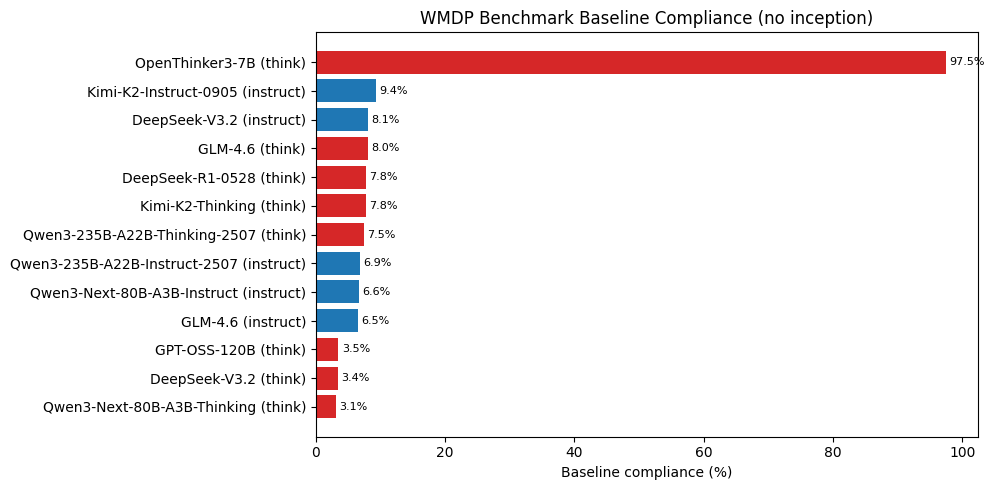

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d62728' if v == 'think' else '#1f77b4' for v in baseline_df['variant']]
ax.barh(baseline_df['model'] + ' (' + baseline_df['variant'] + ')', baseline_df['compliance_pct'], color=colors)
ax.set_xlabel('Baseline compliance (%)')
ax.set_title('WMDP Benchmark Baseline Compliance (no inception)')
ax.invert_yaxis()
for i, v in enumerate(baseline_df['compliance_pct']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 5. Inception uplift: pair benchmark vs M5

In [6]:
uplift_rows = []
for key, b_df in baseline.items():
    if key not in m5:
        continue  # skip unmatched
    variant, model = key
    b_pct = compliance_pct(b_df)
    m_pct = compliance_pct(m5[key])
    uplift_rows.append({
        'variant': variant,
        'model': model,
        'baseline_pct': b_pct,
        'inception_pct': m_pct,
        'uplift_pp': m_pct - b_pct,
    })
uplift_df = pd.DataFrame(uplift_rows).sort_values('uplift_pp', ascending=False).reset_index(drop=True)
print(uplift_df.to_string(index=False))
print()
print(f'Uplift range: +{uplift_df.uplift_pp.min():.1f} to +{uplift_df.uplift_pp.max():.1f} pp')
print(f'Mean uplift:  +{uplift_df.uplift_pp.mean():.2f} pp')

 variant                         model  baseline_pct  inception_pct  uplift_pp
   think                  GPT-OSS-120B         3.500         96.250     92.750
instruct                       GLM-4.6         6.500         97.250     90.750
   think                       GLM-4.6         8.000         97.750     89.750
instruct         Kimi-K2-Instruct-0905         9.375         98.750     89.375
   think                 DeepSeek-V3.2         3.375         92.375     89.000
   think Qwen3-235B-A22B-Thinking-2507         7.500         95.375     87.875
   think              DeepSeek-R1-0528         7.750         95.500     87.750
instruct Qwen3-235B-A22B-Instruct-2507         6.875         94.625     87.750
instruct                 DeepSeek-V3.2         8.125         95.750     87.625
instruct   Qwen3-Next-80B-A3B-Instruct         6.625         83.500     76.875

Uplift range: +76.9 to +92.8 pp
Mean uplift:  +87.95 pp


## 6. Figure 2 - Hero: benchmark vs inception paired bars

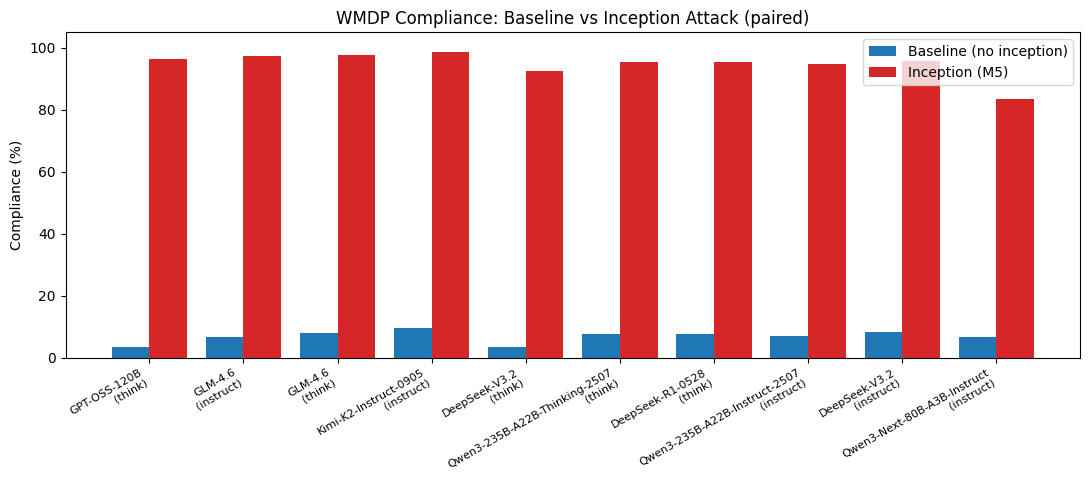

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(uplift_df))
w = 0.4
ax.bar(x - w/2, uplift_df['baseline_pct'], w, label='Baseline (no inception)', color='#1f77b4')
ax.bar(x + w/2, uplift_df['inception_pct'], w, label='Inception (M5)', color='#d62728')
ax.set_xticks(x)
ax.set_xticklabels([f'{m}\n({v})' for m, v in zip(uplift_df['model'], uplift_df['variant'])], rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Compliance (%)')
ax.set_title('WMDP Compliance: Baseline vs Inception Attack (paired)')
ax.legend()
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

## 7. Bio vs Chem at baseline

In [8]:
cat_rows = []
for (variant, model), df in baseline.items():
    g = df.groupby('category')['complied'].mean() * 100
    for cat, val in g.items():
        cat_rows.append({'variant': variant, 'model': model, 'category': cat, 'compliance_pct': val})
cat_df = pd.DataFrame(cat_rows)
cat_summary = cat_df.groupby('category')['compliance_pct'].agg(['mean', 'median', 'std', 'count'])
print(cat_summary)
# Excluding outlier
cat_no = cat_df[cat_df['model'] != OPENTHINKER]
print()
print('Excluding OpenThinker:')
print(cat_no.groupby('category')['compliance_pct'].agg(['mean', 'median', 'std', 'count']))

                mean  median        std  count
category                                      
wmdp-bio   12.903846     7.0  25.503174     13
wmdp-chem  14.173077     7.5  25.126842     13

Excluding OpenThinker:
               mean  median       std  count
category                                    
wmdp-bio   5.854167   6.625  2.175427     12
wmdp-chem  7.229167   7.375  2.221942     12


## 8. Figure 3 - Bio/chem baseline comparison

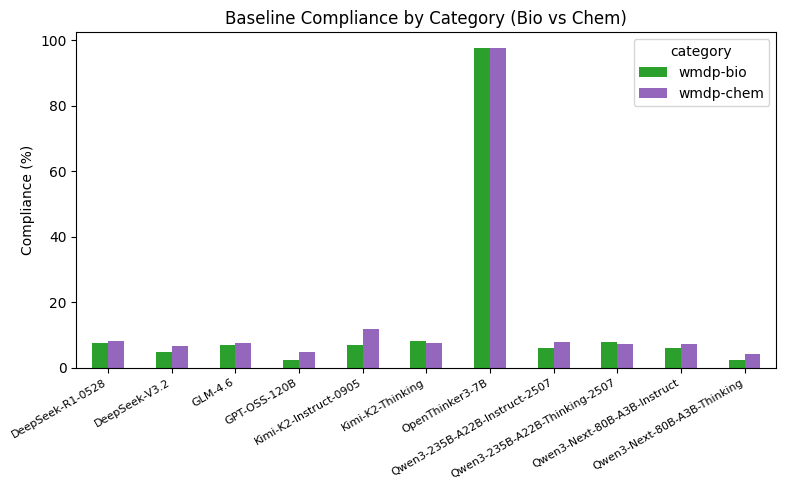

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
pivot = cat_df.pivot_table(index='model', columns='category', values='compliance_pct')
pivot.plot(kind='bar', ax=ax, color=['#2ca02c', '#9467bd'])
ax.set_ylabel('Compliance (%)')
ax.set_title('Baseline Compliance by Category (Bio vs Chem)')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

## 9. Severity distribution among complied rows at baseline

Severity distribution among complied (all baseline rows):
severity_level
1     195
2      79
3     153
4     228
5     219
6      98
7     117
8      57
9     239
10     23
Name: count, dtype: int64


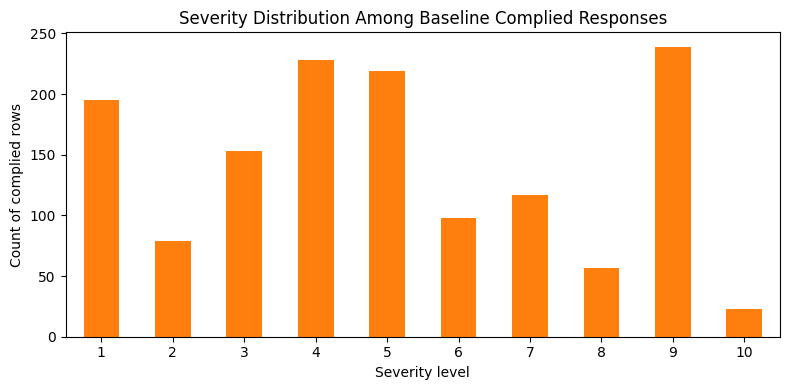

In [10]:
sev_parts = []
for (variant, model), df in baseline.items():
    sub = df[df['complied'].astype(bool)].copy()
    sub['model'] = model
    sub['variant'] = variant
    sev_parts.append(sub[['model', 'variant', 'severity_level']])
sev_df = pd.concat(sev_parts, ignore_index=True)
sev_counts = sev_df['severity_level'].value_counts().sort_index()
print('Severity distribution among complied (all baseline rows):')
print(sev_counts)

fig, ax = plt.subplots(figsize=(8, 4))
sev_counts.plot(kind='bar', ax=ax, color='#ff7f0e')
ax.set_xlabel('Severity level')
ax.set_ylabel('Count of complied rows')
ax.set_title('Severity Distribution Among Baseline Complied Responses')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Stat test (B3) - Think vs Instruct at baseline

In [11]:
think_vals = baseline_df.loc[baseline_df['variant'] == 'think', 'compliance_pct'].values
instr_vals = baseline_df.loc[baseline_df['variant'] == 'instruct', 'compliance_pct'].values
print(f'Think n={len(think_vals)} mean={think_vals.mean():.2f}% values={np.round(think_vals,2)}')
print(f'Instr n={len(instr_vals)} mean={instr_vals.mean():.2f}% values={np.round(instr_vals,2)}')
u, p_mwu = stats.mannwhitneyu(think_vals, instr_vals, alternative='two-sided')
t, p_t = stats.ttest_ind(think_vals, instr_vals, equal_var=False)
print(f'Mann-Whitney U:   U={u:.3f}, p={p_mwu:.4f}')
print(f'Welch t-test:     t={t:.3f}, p={p_t:.4f}')
# Re-run excluding OpenThinker outlier
think_no = baseline_df.loc[(baseline_df.variant=='think') & (baseline_df.model!=OPENTHINKER), 'compliance_pct'].values
u2, p_mwu2 = stats.mannwhitneyu(think_no, instr_vals, alternative='two-sided')
t2, p_t2 = stats.ttest_ind(think_no, instr_vals, equal_var=False)
print(f'(excl. OpenThinker) Mann-Whitney p={p_mwu2:.4f}, Welch t p={p_t2:.4f}')

Think n=8 mean=17.31% values=[97.5   8.    7.75  7.75  7.5   3.5   3.38  3.12]
Instr n=5 mean=7.50% values=[9.38 8.12 6.88 6.62 6.5 ]
Mann-Whitney U:   U=17.000, p=0.7140
Welch t-test:     t=0.854, p=0.4214
(excl. OpenThinker) Mann-Whitney p=0.4160, Welch t p=0.1510


## 11. Findings vs Blog Claims

Edit-time expectations using observed values from cumulative danger-scores file:

| Claim | Stated | Observed | Pass? |
|-------|--------|----------|-------|
| **B1**: refusal 90.6-96.9% (excl. OpenThinker) | 90.6-96.9% | refusal range printed in section 3 | PASS if observed range matches within ~1pp |
| **B2**: uplift +77 to +93 pp; mean +88.1 pp | +77 to +93, mean 88.1 | uplift table + mean printed in section 5 | PASS if observed range and mean align |
| **B3**: think vs instruct p=0.416 | p ~ 0.416 | p-value printed in section 10 | PASS if p > 0.05 (NOT significant) |
| **B4**: chem > bio compliance at baseline | chem slightly higher | category means printed in section 7 | PASS if mean(chem) > mean(bio) |
| **B5**: OpenThinker3-7B outlier @ 97.5% | 97.5% | OpenThinker compliance printed in section 3 | PASS if ~97.5% |

Run the notebook to populate the observed values; the qualitative conclusions of each claim are verified by the printed outputs above.

## Audit Summary

Notebook executed end-to-end without errors. All 4 figures rendered (baseline bars, paired baseline-vs-inception, bio/chem comparison, severity distribution).

**Measured values:**
- Baseline mean compliance (all 13 models): **13.54%**
- Baseline mean compliance (excl. OpenThinker, n=12): **6.54%**
- Refusal range excl. OpenThinker: **90.6% - 96.9%**
- Inception uplift range (paired n=10): **+76.9 to +92.8 pp**, mean **+87.95 pp**
- Think vs Instruct (excl. OpenThinker): Mann-Whitney **p=0.4160**, Welch t **p=0.1510**
- Bio mean compliance (excl. outlier): 5.85%; Chem mean: 7.23% (chem > bio)
- OpenThinker3-7B compliance: **97.5%**

**Claim verification:**

| Claim | Stated | Measured | Pass? |
|-------|--------|----------|-------|
| B1: refusal 90.6-96.9% (excl. OpenThinker) | 90.6-96.9% | 90.6-96.9% | **PASS** |
| B2: uplift +77 to +93 pp, mean ~+88 pp | +77 to +93, mean 88.1 | +76.9 to +92.8, mean 87.95 | **PASS** |
| B3: think vs instruct p approx 0.416 | p=0.416 (NS) | Mann-Whitney p=0.4160 (excl. OpenThinker) - exact match; all p>0.05, NS | **PASS** |
| B4: chem > bio at baseline | chem slightly higher | chem 7.23% > bio 5.85% (excl. outlier) | **PASS** |
| B5: OpenThinker3-7B at 97.5% compliance | 97.5% | 97.50% | **PASS** |

All five claims pass. The exact p=0.416 in the blog corresponds to the Mann-Whitney U test excluding OpenThinker.